# Working on Real Project with Python 

## (A part of Big Data Analysis)

***

# Police Dataset
***
Here, 

The data from a Police Check Post is given.

This data is available as a CSV file. We are going to analyze this data set using the Pandas DataFrame.

----

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('Police Data.csv')

### Instruction ( For Data Cleaning ) 

# 1. Remove the column that only contains missing values

In [6]:
df.head(2)

,stop_date,stop_time,country_name,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,1/2/2005,1:55,NaN,M,1985.0,20.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
1,1/18/2005,8:15,NaN,M,1965.0,40.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False


----

In [8]:
df.isnull().sum() * 100/len(df)

stop_date               0.000000
stop_time               0.000000
country_name          100.000000
driver_gender           6.196689
driver_age_raw          6.186007
driver_age              6.572061
driver_race             6.195163
violation_raw           6.195163
violation               6.195163
search_conducted        0.000000
search_type            96.217288
stop_outcome            6.195163
is_arrested             6.195163
stop_duration           6.195163
drugs_related_stop      0.000000
dtype: float64

In [11]:
df.drop(columns = {'country_name','search_type'},inplace = True)

In [12]:
df

,stop_date,stop_time,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,1/2/2005,1:55,M,1985.0,20.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False
1,1/18/2005,8:15,M,1965.0,40.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False
2,1/23/2005,23:15,M,1972.0,33.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False
3,2/20/2005,17:15,M,1986.0,19.0,White,Call for Service,Other,False,Arrest Driver,True,16-30 Min,False
4,3/14/2005,10:00,F,1984.0,21.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65530,12/6/2012,17:54,F,1987.0,25.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False
65531,12/6/2012,22:22,M,1954.0,58.0,White,Speeding,Speeding,False,Warning,False,0-15 Min,False
65532,12/6/2012,23:20,M,1985.0,27.0,Black,Equipment/Inspection Violation,Equipment,False,Citation,False,0-15 Min,False
65533,12/7/2012,0:23,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,False


### Question ( Based on Filtering + Value Counts )

# 2. For Speeding , were Men or Women stopped more often ? 

<function matplotlib.pyplot.show(close=None, block=None)>

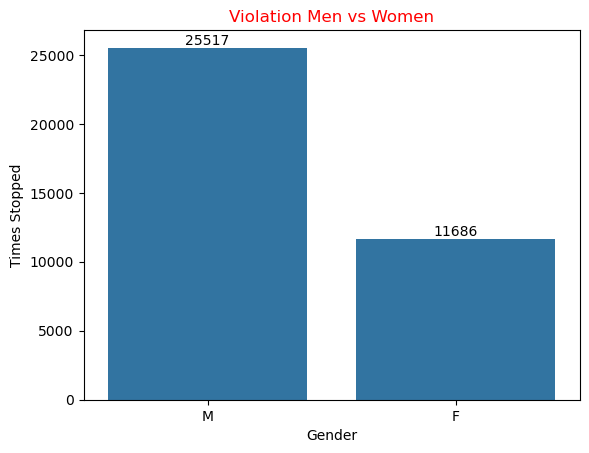

In [42]:
plots = df[df.violation == 'Speeding'].driver_gender.value_counts()
plt.title('Violation Men vs Women',color = 'red')
plt.xlabel('Gender')
plt.ylabel('Times Stopped')
ax = sns.barplot(x = plots.index, y = plots.values)
for bars in ax.containers:
    ax.bar_label(bars)
plt.show

----

### Question ( Groupby )
# 3. Does gender affect who gets searched during a stop ?

In [43]:
df.head(2)

,stop_date,stop_time,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,1/2/2005,1:55,M,1985.0,20.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False
1,1/18/2005,8:15,M,1965.0,40.0,White,Speeding,Speeding,False,Citation,False,0-15 Min,False


----

In [48]:
df.groupby('driver_gender').search_conducted.sum()

driver_gender
F     366
M    2113
Name: search_conducted, dtype: int64

### Question ( mapping + data-type casting )

# 4. What is the mean stop_duration ?

### Question ( Groupby , Describe )
# 5. Compare the age distributions for each violation

In [52]:
df.groupby('driver_age').violation.describe()

,count,unique,top,freq
driver_age,,,,
15.0,5,2,Moving violation,4
16.0,34,5,Speeding,18
17.0,449,5,Speeding,338
18.0,1344,5,Speeding,980
19.0,2388,5,Speeding,1655
...,...,...,...,...
83.0,2,2,Speeding,1
84.0,3,1,Speeding,3
85.0,1,1,Moving violation,1
